In [2]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 2.4 MB/s  0:00:30 eta 0:00:010:00:02


In [3]:
# Can Scanner 
# Image transormation -> translate Rotate Resize
# Perspective transform


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
img=cv2.imread("z1.png")

In [7]:
img.shape

(1500, 2667, 3)

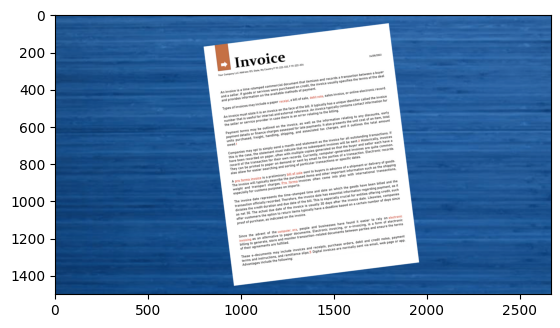

In [10]:
plt.imshow(img)
plt.show()

In [9]:

rows, cols=img.shape[:2]

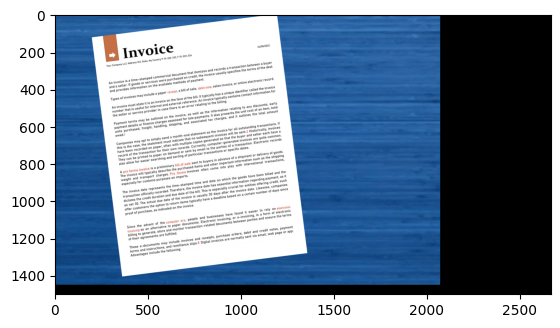

In [13]:
# 1 TRANSLATE Image 
# make translate matrix jisme aap baoge x y z axis mein kitna translte krna chahte ho
# format-> [[1,0,tx],[0,1,ty]]
# tx- shift along x axis
# ty- shift along y axis
matrix=np.float32([[1,0,-600],[0,1,-50]])

# Apply translation
# params; (image , translate_matrix, ouput_size)

translate=cv2.warpAffine(img, matrix, (cols, rows))
plt.imshow(translate)
plt.show()

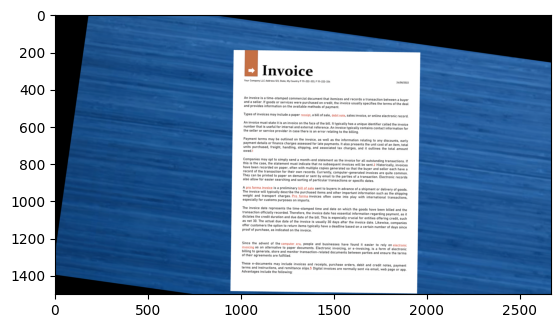

In [30]:
# 2 Rotation
# center of image from where u do rotation
center=(rows//2, cols//2)
# Parameter: (center, angle, scale)
# Angle- rotations in degrees  (positive= counter clcokwise)
# Scale -zoom (default=1)
matrix=cv2.getRotationMatrix2D(center, -8,1)
rotated=cv2.warpAffine(img,matrix, (cols, rows))
plt.imshow(rotated)
plt.show()

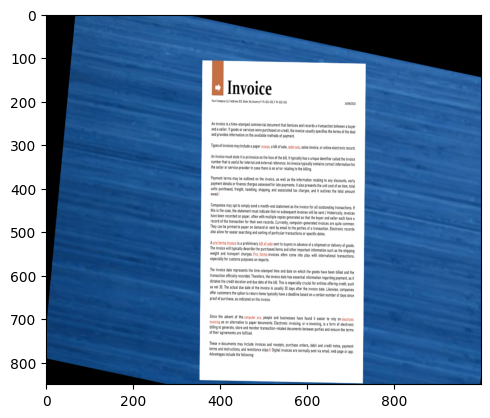

In [31]:
# 3 Resize
resized=cv2.resize(rotated,(1000,850))
plt.imshow(resized)
plt.show()

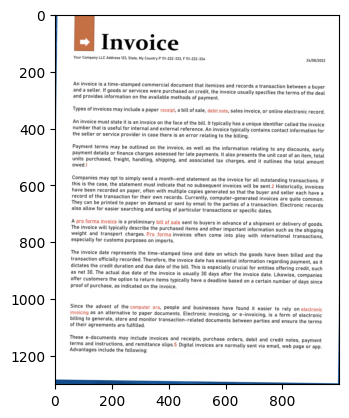

In [32]:
# 4 Cropping Filtering
# rotated[start_y:end_y, start_x:end_y] -> first argument cuts height or y   and sec one is for col /x
cropped=rotated[200:, 950:1950]
plt.imshow(cropped)
plt.show()

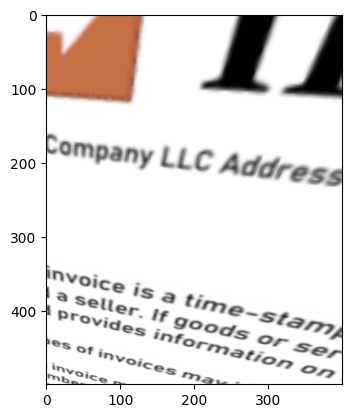

In [35]:
# 5 Perspective Transform(not neccessary for this image)
# Convert tilted documnet - top-doen flat view
# Source points: [top:left], top_right, bottom-right, bottom-left]
points1=np.float32([[100,100],[200,100],[300,300],[80,420]])
# Destinations points
points2=np.float32([[0,0],[400,0],[400,500],[0,500]])
# Compute perspective 
matrix=cv2.getPerspectiveTransform(points1, points2)
warped=cv2.warpPerspective(cropped, matrix, [400,500])
plt.imshow(warped)
plt.show()